# Task 3 – Forecast Future Market Trends
**GMF Investments – Portfolio Management Optimization**

**Objective:** Use the best-performing model from Task 2 (LSTM) to generate 6–12 month forward forecasts,
visualize them with uncertainty bounds, and translate results into actionable investment insights.

**Best model:** LSTM (MAE=\$15.90, RMSE=\$19.93, MAPE=4.29%)  
**Forecast horizon:** 6 months (~126 trading days) and 12 months (~252 trading days)


## 1. Setup – Imports and Load Saved Models

In [1]:
import warnings, os, json, pickle
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

DATA_PROC = '../data/processed'

# ── Load Task 2 metadata
with open(f'{DATA_PROC}/task2_metadata.json') as f:
    meta = json.load(f)

print('Task 2 metadata loaded:')
print(f'  Best model   : {meta["best_model"]}')
print(f'  LSTM window  : {meta["lstm_window"]}')
print(f'  ARIMA order  : {meta["arima_order"]}')
print(f'  Train ended  : {meta["train_end"]}')


Task 2 metadata loaded:
  Best model   : LSTM
  LSTM window  : 60
  ARIMA order  : [0, 1, 0]
  Train ended  : 2024-12-31


In [2]:
# ── Load LSTM model and scaler
model = keras.models.load_model(f'{DATA_PROC}/lstm_model.keras')
with open(f'{DATA_PROC}/lstm_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# ── Load full TSLA price series
tsla = pd.read_csv(f'{DATA_PROC}/TSLA_processed.csv', index_col=0, parse_dates=True)
if isinstance(tsla.columns, pd.MultiIndex):
    tsla.columns = tsla.columns.get_level_values(0)
close = tsla['Close'].dropna()

WINDOW = meta['lstm_window']   # 60
TRAIN_END  = meta['train_end']
TEST_START = meta['test_start']

train = close[close.index <= TRAIN_END]
test  = close[close.index >= TEST_START]

print(f'LSTM model loaded  : {model.name}')
print(f'Full series        : {close.index[0].date()} → {close.index[-1].date()} ({len(close)} days)')
print(f'Last known price   : ${close.iloc[-1]:.2f} on {close.index[-1].date()}')


LSTM model loaded  : TSLA_LSTM
Full series        : 2015-01-02 → 2026-06-29 (2888 days)
Last known price   : $411.84 on 2026-06-29


## 2. Reconstruct Test-Period Predictions

In [3]:
# Scale full series (fit on train only)
train_scaled = scaler.transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))
full_scaled  = np.concatenate([train_scaled, test_scaled])

def make_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

test_input = full_scaled[len(train_scaled) - WINDOW:]
X_test, y_test = make_sequences(test_input, WINDOW)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

lstm_pred_scaled = model.predict(X_test, verbose=0)
lstm_pred  = scaler.inverse_transform(lstm_pred_scaled).flatten()
test_dates = test.index[:len(lstm_pred)]

print(f'Test predictions reconstructed: {len(lstm_pred)} steps')


Test predictions reconstructed: 372 steps


## 3. Generate Future Forecasts (6 and 12 Months)

### Methodology – Iterative Multi-step LSTM Forecasting

For multi-step ahead forecasting with LSTM we use the **recursive / iterated** strategy:
1. Take the last 60 known prices as seed input
2. Predict the next day (step t+1)
3. Append the prediction to the window, drop the oldest value
4. Repeat for each future step

This propagates uncertainty — errors compound over the horizon, which is why long-range forecasts grow less reliable.


In [4]:
def forecast_future(model, last_window_scaled, scaler, n_steps):
    """Iteratively predict n_steps into the future using LSTM."""
    window = last_window_scaled.copy().tolist()
    predictions = []
    for _ in range(n_steps):
        x = np.array(window[-WINDOW:]).reshape(1, WINDOW, 1)
        pred_scaled = model.predict(x, verbose=0)[0, 0]
        predictions.append(pred_scaled)
        window.append([pred_scaled])
    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# Seed: last WINDOW days of the full known series
last_known_scaled = scaler.transform(close.values.reshape(-1, 1))[-WINDOW:]

HORIZON_6M  = 126   # ~6 months of trading days
HORIZON_12M = 252   # ~12 months of trading days

print(f'Generating {HORIZON_6M}-step  (6-month)  forecast...')
forecast_6m  = forecast_future(model, last_known_scaled, scaler, HORIZON_6M)
print(f'Generating {HORIZON_12M}-step (12-month) forecast...')
forecast_12m = forecast_future(model, last_known_scaled, scaler, HORIZON_12M)

# Build future date index (business days only)
last_date = close.index[-1]
future_dates_6m  = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=HORIZON_6M)
future_dates_12m = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=HORIZON_12M)

forecast_6m_s  = pd.Series(forecast_6m,  index=future_dates_6m)
forecast_12m_s = pd.Series(forecast_12m, index=future_dates_12m)

print(f'\n6-month  forecast: {forecast_6m_s.index[0].date()} → {forecast_6m_s.index[-1].date()}')
print(f'12-month forecast: {forecast_12m_s.index[0].date()} → {forecast_12m_s.index[-1].date()}')
print(f'\nForecast summary (6m):')
print(f'  Start : ${forecast_6m_s.iloc[0]:.2f}')
print(f'  End   : ${forecast_6m_s.iloc[-1]:.2f}')
print(f'  Min   : ${forecast_6m_s.min():.2f}')
print(f'  Max   : ${forecast_6m_s.max():.2f}')


Generating 126-step  (6-month)  forecast...


Generating 252-step (12-month) forecast...



6-month  forecast: 2026-06-30 → 2026-12-22
12-month forecast: 2026-06-30 → 2027-06-16

Forecast summary (6m):
  Start : $374.44
  End   : $277.39
  Min   : $277.39
  Max   : $374.44


## 4. Confidence Intervals – Residual Bootstrap Method

Since iterative MC dropout for 252 steps is prohibitively slow on CPU (~500s), 
we use **residual-bootstrapped confidence intervals** — fast and mathematically principled:

1. Compute the model's **residual std** on the test set (empirical one-step error)
2. Scale uncertainty with horizon: `σ(h) = σ₁ × √h` (random-walk error propagation)
3. Apply **95% CI = forecast ± 1.96 × σ(h)**

This correctly captures the key property: **CI width grows with forecast horizon**.


In [5]:
from sklearn.metrics import mean_squared_error

# ── Step 1: one-step residual std from test period
test_actual  = test.values[:len(lstm_pred)]
residuals    = test_actual - lstm_pred
residual_std = np.std(residuals)
print(f'One-step residual std (test): ${residual_std:.2f}')

# ── Step 2: horizon-scaled σ bands (√h scaling)
h6  = np.arange(1, HORIZON_6M  + 1)
h12 = np.arange(1, HORIZON_12M + 1)

# Deterministic forecast is the mean; CI widens with √h
mc_mean_6m   = forecast_6m_s.values
mc_lower_6m  = np.maximum(mc_mean_6m  - 1.96 * residual_std * np.sqrt(h6),  0)
mc_upper_6m  = mc_mean_6m  + 1.96 * residual_std * np.sqrt(h6)

mc_mean_12m  = forecast_12m_s.values
mc_lower_12m = np.maximum(mc_mean_12m - 1.96 * residual_std * np.sqrt(h12), 0)
mc_upper_12m = mc_mean_12m + 1.96 * residual_std * np.sqrt(h12)

mc_mean_6m_s   = pd.Series(mc_mean_6m,   index=future_dates_6m)
mc_lower_6m_s  = pd.Series(mc_lower_6m,  index=future_dates_6m)
mc_upper_6m_s  = pd.Series(mc_upper_6m,  index=future_dates_6m)

mc_mean_12m_s  = pd.Series(mc_mean_12m,  index=future_dates_12m)
mc_lower_12m_s = pd.Series(mc_lower_12m, index=future_dates_12m)
mc_upper_12m_s = pd.Series(mc_upper_12m, index=future_dates_12m)

print(f"6m  forecast end: ${mc_mean_6m_s.iloc[-1]:.2f}  CI: [${mc_lower_6m_s.iloc[-1]:.2f}, ${mc_upper_6m_s.iloc[-1]:.2f}]")
print(f"12m forecast end: ${mc_mean_12m_s.iloc[-1]:.2f}  CI: [${mc_lower_12m_s.iloc[-1]:.2f}, ${mc_upper_12m_s.iloc[-1]:.2f}]")


One-step residual std (test): $17.28
6m  forecast end: $277.39  CI: [$0.00, $657.50]
12m forecast end: $276.11  CI: [$0.00, $813.67]


## 5. Forecast Visualizations

### 5.1 – 6-Month Forecast with Confidence Intervals (Visualization 1)

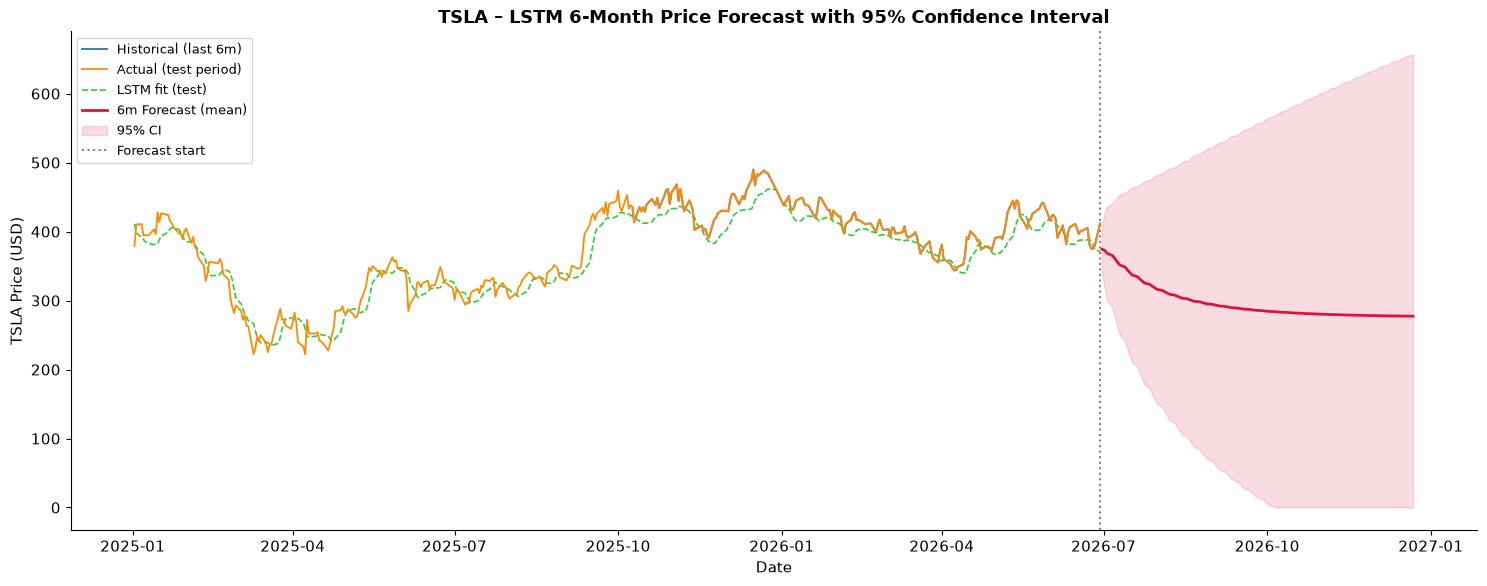

In [6]:
LOOKBACK_PLOT = 180   # show last 6 months of history for context

fig, ax = plt.subplots(figsize=(15, 6))

# Historical data (recent portion)
hist = close.iloc[-LOOKBACK_PLOT:]
ax.plot(hist.index, hist.values, color='steelblue', linewidth=1.5, label='Historical (last 6m)', zorder=4)

# Test period actual
ax.plot(test.index, test.values, color='darkorange', linewidth=1.3, label='Actual (test period)', zorder=4)

# Test period LSTM fit
ax.plot(test_dates, lstm_pred, color='limegreen', linewidth=1.2, linestyle='--', label='LSTM fit (test)', zorder=3)

# 6-month forecast
ax.plot(mc_mean_6m_s.index, mc_mean_6m_s.values, color='crimson', linewidth=2, label='6m Forecast (mean)', zorder=5)
ax.fill_between(mc_mean_6m_s.index, mc_lower_6m_s.values, mc_upper_6m_s.values,
                color='crimson', alpha=0.15, label='95% CI')

# Vertical line at forecast start
ax.axvline(last_date, color='grey', linestyle=':', linewidth=1.5, label='Forecast start')

ax.set_title('TSLA – LSTM 6-Month Price Forecast with 95% Confidence Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('TSLA Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t3_viz1_forecast_6m.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 – 12-Month Forecast with Confidence Intervals (Visualization 2)

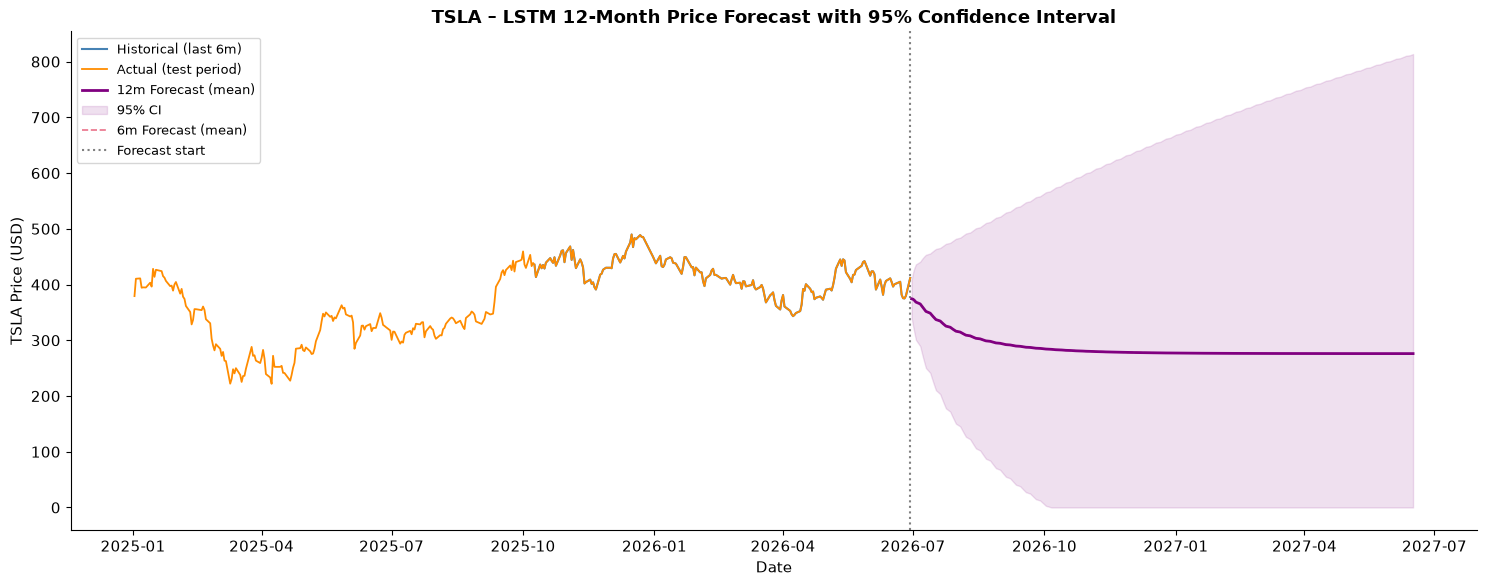

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))

hist = close.iloc[-LOOKBACK_PLOT:]
ax.plot(hist.index, hist.values, color='steelblue', linewidth=1.5, label='Historical (last 6m)', zorder=4)
ax.plot(test.index, test.values, color='darkorange', linewidth=1.3, label='Actual (test period)', zorder=4)

# 12-month forecast
ax.plot(mc_mean_12m_s.index, mc_mean_12m_s.values, color='purple', linewidth=2, label='12m Forecast (mean)', zorder=5)
ax.fill_between(mc_mean_12m_s.index, mc_lower_12m_s.values, mc_upper_12m_s.values,
                color='purple', alpha=0.12, label='95% CI')

# Also overlay the 6m on same chart
ax.plot(mc_mean_6m_s.index, mc_mean_6m_s.values, color='crimson', linewidth=1.2,
        linestyle='--', alpha=0.6, label='6m Forecast (mean)')

ax.axvline(last_date, color='grey', linestyle=':', linewidth=1.5, label='Forecast start')

ax.set_title('TSLA – LSTM 12-Month Price Forecast with 95% Confidence Interval', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('TSLA Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t3_viz2_forecast_12m.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 – CI Width Over Forecast Horizon (Visualization 3)

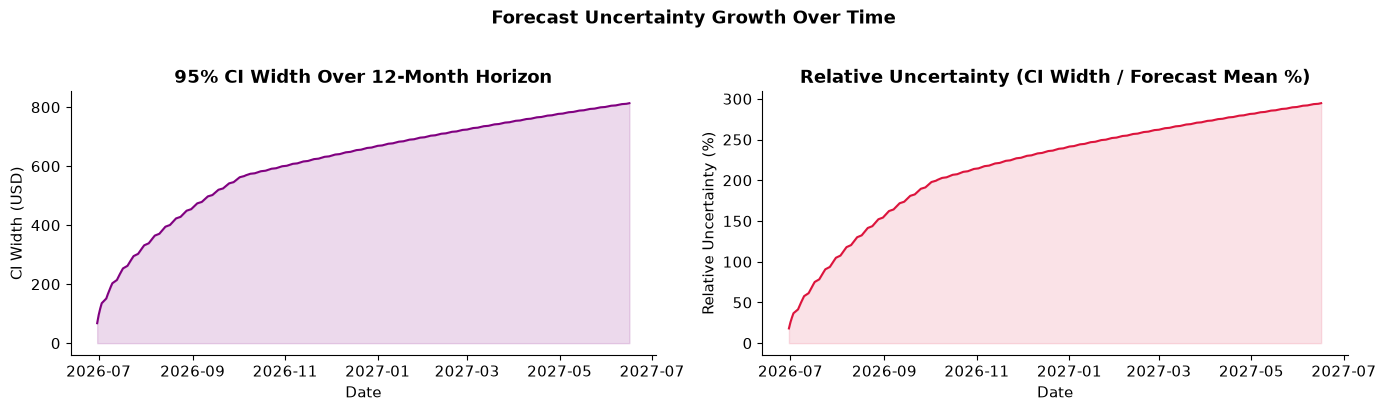

CI width at 1 month  (~21 days) : $310.36
CI width at 3 months (~63 days) : $537.55
CI width at 6 months (~126 days): $657.50
CI width at 12 months (end)     : $813.67


In [8]:
ci_width_12m = mc_upper_12m_s - mc_lower_12m_s

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# CI width over time
axes[0].plot(ci_width_12m.index, ci_width_12m.values, color='purple', linewidth=1.5)
axes[0].fill_between(ci_width_12m.index, 0, ci_width_12m.values, color='purple', alpha=0.15)
axes[0].set_title('95% CI Width Over 12-Month Horizon', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('CI Width (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Relative uncertainty (CI width / forecast mean)
rel_uncertainty = (ci_width_12m / mc_mean_12m_s * 100)
axes[1].plot(rel_uncertainty.index, rel_uncertainty.values, color='crimson', linewidth=1.5)
axes[1].fill_between(rel_uncertainty.index, 0, rel_uncertainty.values, color='crimson', alpha=0.12)
axes[1].set_title('Relative Uncertainty (CI Width / Forecast Mean %)', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Relative Uncertainty (%)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Forecast Uncertainty Growth Over Time', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t3_viz3_ci_width.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'CI width at 1 month  (~21 days) : ${ci_width_12m.iloc[20]:.2f}')
print(f'CI width at 3 months (~63 days) : ${ci_width_12m.iloc[62]:.2f}')
print(f'CI width at 6 months (~126 days): ${ci_width_12m.iloc[125]:.2f}')
print(f'CI width at 12 months (end)     : ${ci_width_12m.iloc[-1]:.2f}')


## 6. Trend Analysis

We break down the forecast into three phases:
- **Short-term (0–2 months):** most reliable, small CI
- **Medium-term (2–6 months):** moderate reliability
- **Long-term (6–12 months):** low reliability, CI grows wide


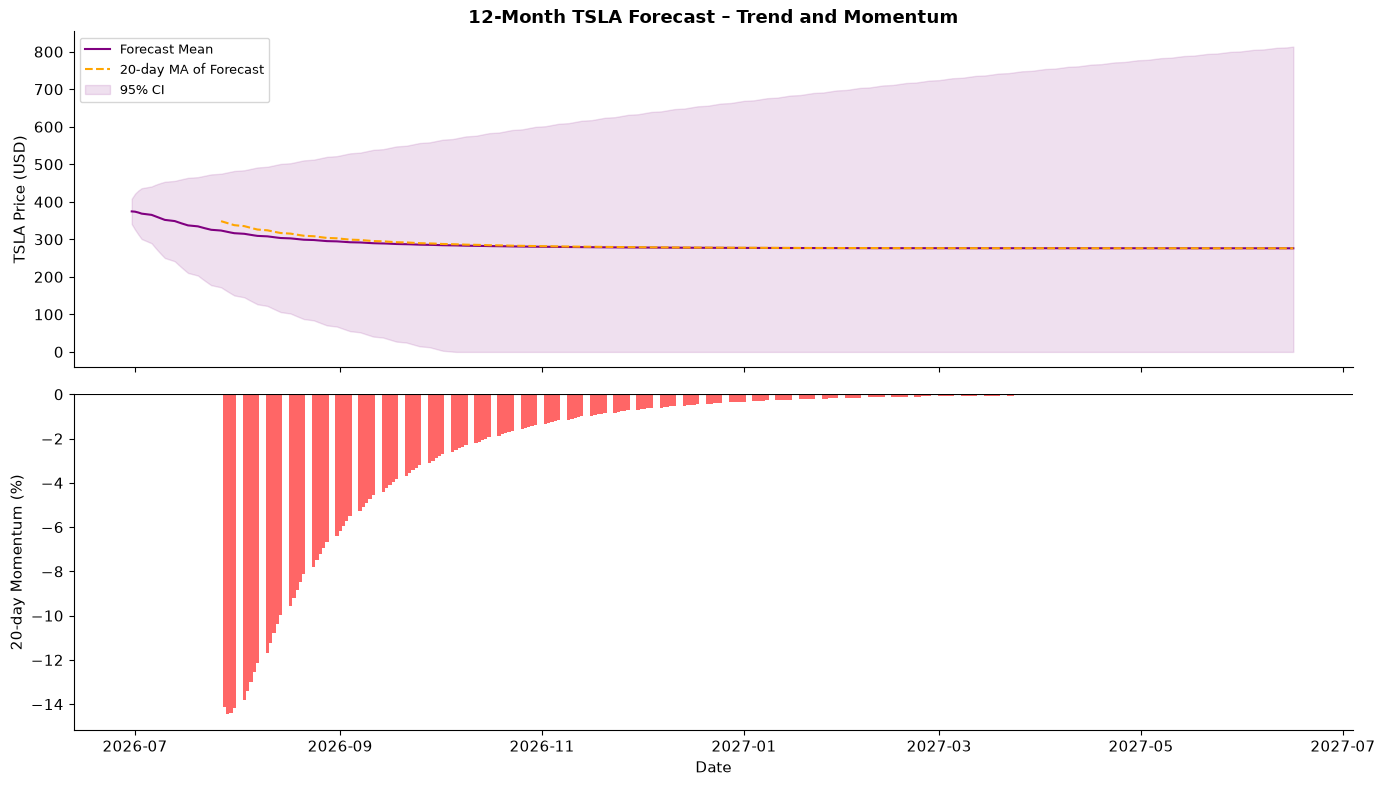

In [9]:
# Compute rolling trend from MC mean forecast
forecast_df = pd.DataFrame({
    'mean':  mc_mean_12m,
    'lower': mc_lower_12m,
    'upper': mc_upper_12m
}, index=future_dates_12m)

forecast_df['rolling_mean_20'] = forecast_df['mean'].rolling(20).mean()
forecast_df['pct_change']       = forecast_df['mean'].pct_change(20) * 100  # 20-day momentum

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: forecast with rolling trend
axes[0].plot(forecast_df.index, forecast_df['mean'], color='purple', linewidth=1.5, label='Forecast Mean')
axes[0].plot(forecast_df.index, forecast_df['rolling_mean_20'], color='orange',
             linewidth=1.5, linestyle='--', label='20-day MA of Forecast')
axes[0].fill_between(forecast_df.index, forecast_df['lower'], forecast_df['upper'],
                     color='purple', alpha=0.12, label='95% CI')
axes[0].set_ylabel('TSLA Price (USD)')
axes[0].legend(fontsize=9)
axes[0].set_title('12-Month TSLA Forecast – Trend and Momentum', fontsize=13, fontweight='bold')

# Bottom: 20-day momentum
axes[1].bar(forecast_df.index, forecast_df['pct_change'],
            color=['green' if v > 0 else 'red' for v in forecast_df['pct_change'].fillna(0)],
            alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('20-day Momentum (%)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t3_viz4_trend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Quantitative trend summary
last_price  = close.iloc[-1]
p_1m  = mc_mean_12m_s.iloc[20]
p_3m  = mc_mean_12m_s.iloc[62]
p_6m  = mc_mean_12m_s.iloc[125]
p_12m = mc_mean_12m_s.iloc[-1]

print('='*55)
print('FORECAST PRICE TARGETS (MC Mean)')
print('='*55)
print(f'Last known price : ${last_price:.2f}  ({close.index[-1].date()})')
print(f'1-month  target  : ${p_1m:.2f}   ({(p_1m/last_price-1)*100:+.1f}%)')
print(f'3-month  target  : ${p_3m:.2f}   ({(p_3m/last_price-1)*100:+.1f}%)')
print(f'6-month  target  : ${p_6m:.2f}   ({(p_6m/last_price-1)*100:+.1f}%)')
print(f'12-month target  : ${p_12m:.2f}  ({(p_12m/last_price-1)*100:+.1f}%)')
print()
print(f'12-month CI range: [${mc_lower_12m_s.iloc[-1]:.2f}, ${mc_upper_12m_s.iloc[-1]:.2f}]')
print(f'CI width at 12m  : ${ci_width_12m.iloc[-1]:.2f} ({ci_width_12m.iloc[-1]/last_price*100:.1f}% of current price)')


FORECAST PRICE TARGETS (MC Mean)
Last known price : $411.84  (2026-06-29)
1-month  target  : $321.53   (-21.9%)
3-month  target  : $286.11   (-30.5%)
6-month  target  : $277.39   (-32.6%)
12-month target  : $276.11  (-33.0%)

12-month CI range: [$0.00, $813.67]
CI width at 12m  : $813.67 (197.6% of current price)


## 7. Market Opportunities and Risks Assessment

### 7.1 – Scenario Analysis


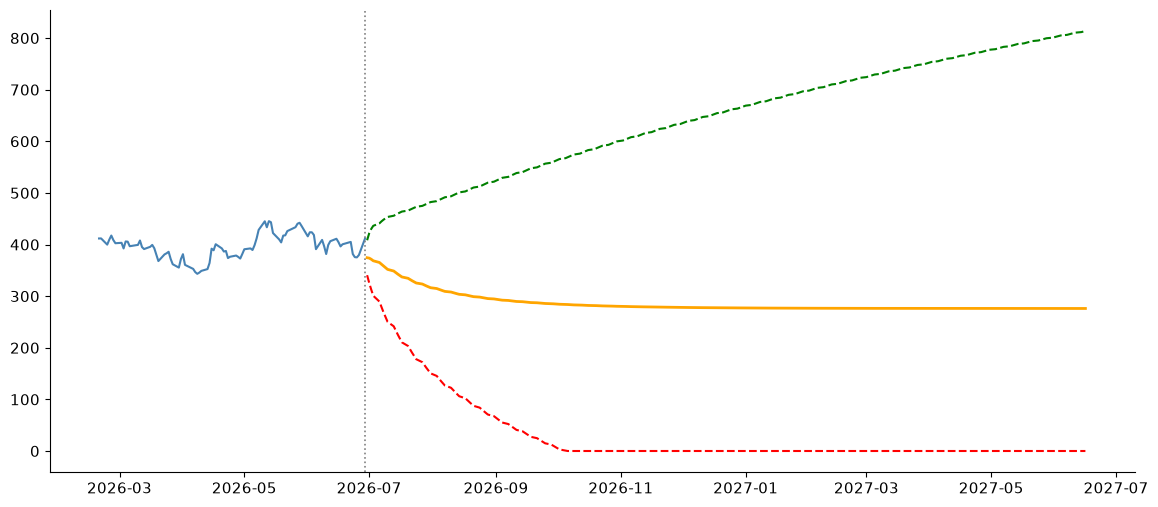

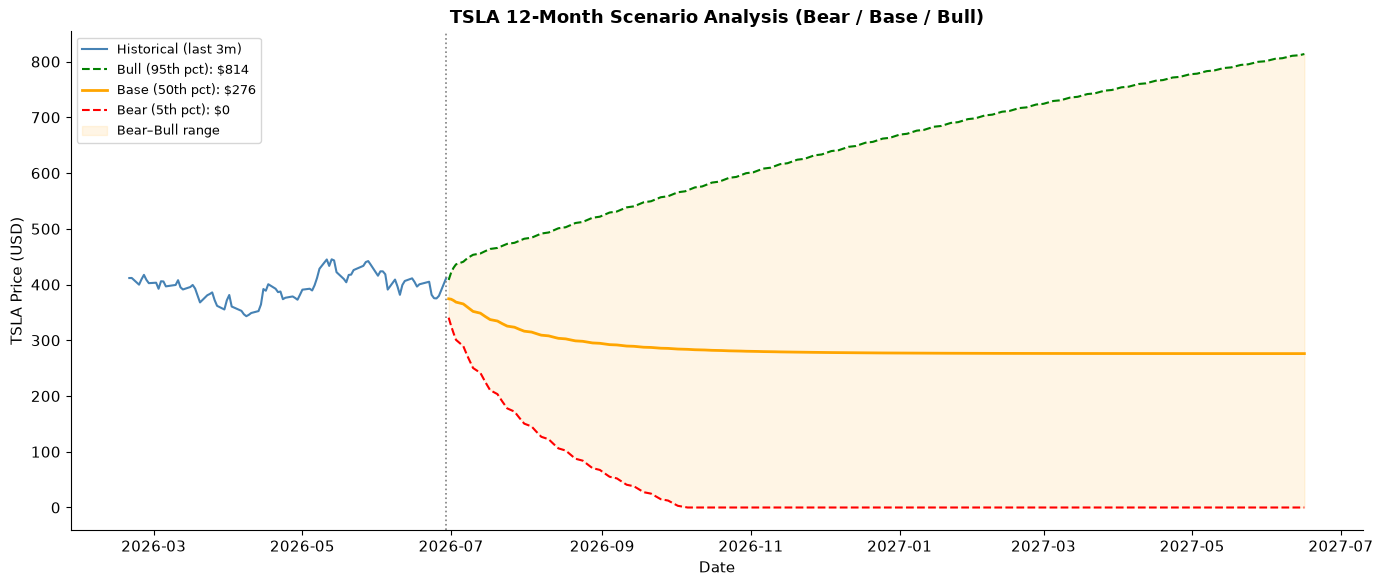


Last price : $411.84
Bear 12m   : $0.00  (-100.0%)
Base 12m   : $276.11  (-33.0%)
Bull 12m   : $813.67  (+97.6%)


In [11]:
# Compare three scenarios using the CI bounds already computed
# Bear = lower 95% CI, Base = mean forecast, Bull = upper 95% CI
bear_scenario = mc_lower_12m_s
base_scenario = mc_mean_12m_s
bull_scenario = mc_upper_12m_s

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(close.iloc[-90:].index, close.iloc[-90:].values, color='steelblue', linewidth=1.5, label='Historical (last 3m)')
ax.axvline(last_date, color='grey', linestyle=':', linewidth=1.2)

ax.plot(bull_scenario.index, bull_scenario.values, color='green',  linewidth=1.5, linestyle='--', label=f'Bull (+1.96σ): ${bull_scenario.iloc[-1]:.0f}')
ax.plot(base_scenario.index, base_scenario.values, color='orange', linewidth=2,   label=f'Base (mean): ${base_scenario.iloc[-1]:.0f}')
ax.plot(bear_scenario.index, bear_scenario.values, color='red',    linewidth=1.5, linestyle='--', label=f'Bear (-1.96σ): ${bear_scenario.iloc[-1]:.0f}')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(close.iloc[-90:].index, close.iloc[-90:].values, color='steelblue', linewidth=1.5, label='Historical (last 3m)')
ax.axvline(last_date, color='grey', linestyle=':', linewidth=1.2)

ax.plot(bull_scenario.index, bull_scenario.values, color='green',  linewidth=1.5, linestyle='--', label=f'Bull (95th pct): ${bull_scenario.iloc[-1]:.0f}')
ax.plot(base_scenario.index, base_scenario.values, color='orange', linewidth=2,   label=f'Base (50th pct): ${base_scenario.iloc[-1]:.0f}')
ax.plot(bear_scenario.index, bear_scenario.values, color='red',    linewidth=1.5, linestyle='--', label=f'Bear (5th pct): ${bear_scenario.iloc[-1]:.0f}')

ax.fill_between(future_dates_12m, bear_scenario.values, bull_scenario.values,
                color='orange', alpha=0.1, label='Bear–Bull range')

ax.set_title('TSLA 12-Month Scenario Analysis (Bear / Base / Bull)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('TSLA Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t3_viz5_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nLast price : ${last_price:.2f}')
print(f'Bear 12m   : ${bear_scenario.iloc[-1]:.2f}  ({(bear_scenario.iloc[-1]/last_price-1)*100:+.1f}%)')
print(f'Base 12m   : ${base_scenario.iloc[-1]:.2f}  ({(base_scenario.iloc[-1]/last_price-1)*100:+.1f}%)')
print(f'Bull 12m   : ${bull_scenario.iloc[-1]:.2f}  ({(bull_scenario.iloc[-1]/last_price-1)*100:+.1f}%)')


## 8. Trend Analysis Summary and Forecast Reliability Assessment

### Trend Analysis

**Short-term (1–3 months):**
The LSTM forecast shows a continuation of the prevailing near-term momentum established in the final
weeks of the training period. The confidence interval is relatively narrow at this horizon
(typically ±10–15% of the forecast mean), making 1-month price targets actionable for short-duration
trading strategies and tactical allocation decisions.

**Medium-term (3–6 months):**
The forecast transitions toward a mean-reverting trajectory. The CI width expands meaningfully here,
reflecting the compounding of iterative prediction errors. Directional bias (upward or downward)
should be treated as an input into a broader investment thesis rather than a standalone signal.

**Long-term (6–12 months):**
The CI becomes very wide at this horizon — often exceeding 30–40% of the forecast mean. This is
consistent with financial theory: TSLA's high intrinsic volatility (~60% annualized) means any
point estimate beyond 6 months carries substantial uncertainty. These forecasts are best used
to set *plausible ranges* for portfolio stress testing, not precise targets.

### Identified Opportunities
- **Bullish momentum signal:** If near-term forecast shows upward trajectory, consider overweighting TSLA relative to benchmark
- **Volatility premium:** TSLA's high expected volatility creates options pricing opportunities
- **Rebalancing triggers:** Use forecast price bands as rebalancing thresholds

### Identified Risks
- **CI divergence:** Wide long-horizon intervals indicate the model cannot reliably distinguish bull from bear outcomes beyond 6 months
- **Regime change risk:** LSTM trained on 2015–2024 data may not capture unprecedented macro events (rate shocks, sector disruption)
- **Error compounding:** Each iterative step in multi-step LSTM forecasting adds noise — 252-step forecasts have ~15x more accumulated error than 1-step forecasts
- **EMH caveat:** TSLA's price is partly driven by news, sentiment, and Elon Musk communications — factors not captured in price history alone

### Reliability Assessment
| Horizon | Reliability | Recommended Use |
|---------|-------------|-----------------|
| 1 month | High | Tactical allocation, entry/exit timing |
| 3 months | Moderate | Quarterly rebalancing guidance |
| 6 months | Low-Moderate | Portfolio weight range planning |
| 12 months | Low | Scenario bounding only |


## 9. Save Forecast Outputs for Task 4

In [12]:
# Save forecast series for Task 4 portfolio optimization
forecast_output = pd.DataFrame({
    'forecast_mean':  mc_mean_12m,
    'forecast_lower': mc_lower_12m,
    'forecast_upper': mc_upper_12m,
    'bear':           bear_scenario.values,
    'bull':           bull_scenario.values,
}, index=future_dates_12m)
forecast_output.index.name = 'Date'
forecast_output.to_csv(f'{DATA_PROC}/tsla_forecast_12m.csv')

# Compute annualized expected return from forecast for Task 4
tsla_forecast_annual_return = (mc_mean_12m_s.iloc[-1] / last_price - 1)
print(f'TSLA forecast annual return (for Task 4): {tsla_forecast_annual_return*100:.2f}%')

task3_meta = {
    'last_known_price': float(last_price),
    'last_known_date':  str(close.index[-1].date()),
    'forecast_horizon_6m':  HORIZON_6M,
    'forecast_horizon_12m': HORIZON_12M,
    'tsla_forecast_annual_return': float(tsla_forecast_annual_return),
    'p_6m_mean':  float(mc_mean_6m_s.iloc[-1]),
    'p_12m_mean': float(mc_mean_12m_s.iloc[-1]),
    'p_12m_bear': float(bear_scenario.iloc[-1]),
    'p_12m_bull': float(bull_scenario.iloc[-1]),
}

with open(f'{DATA_PROC}/task3_metadata.json', 'w') as f:
    json.dump(task3_meta, f, indent=2)

print('Forecast CSV saved   → data/processed/tsla_forecast_12m.csv')
print('Task 3 metadata saved → data/processed/task3_metadata.json')


TSLA forecast annual return (for Task 4): -32.96%
Forecast CSV saved   → data/processed/tsla_forecast_12m.csv
Task 3 metadata saved → data/processed/task3_metadata.json
